# Init

In [ ]:
CLS_TRAIN_EPOCHS=50
BIN_TRAIN_EPOCHS=15
UNC_TRAIN_EPOCHS=100

In [ ]:
import inspect
import pathlib
import numpy as np
import keras
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from operator import itemgetter
print('Keras', keras.__version__)
print('Keras Backend:', keras.backend.backend())
print('TensorFlow', tf.__version__)
print('TensorFlow Datasets', tfds.__version__)
print('Numpy', np.__version__)
!python -V

2026-04-28 19:01:51.472373: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777402911.710670      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777402911.761517      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777402912.213035      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777402912.213080      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777402912.213083      22 computation_placer.cc:177] computation placer alr

Keras 3.10.0
Keras Backend: tensorflow
TensorFlow 2.19.0
TensorFlow Datasets 4.9.9
Numpy 2.0.2
Python 3.12.12


In [ ]:
def spectrogram_masking(spectrogram, dim, masks_number=2, mask_max_size=2):
  """Spectrogram masking on frequency or time dimension.
  Args:
    spectrogram: Input spectrum [batch, time, frequency]
    dim: dimension on which masking will be applied: 1 - time; 2 - frequency
    masks_number: number of masks
    mask_max_size: mask max size
  Returns:
    masked spectrogram
  """
  if dim not in (1, 2):
    raise ValueError('Wrong dim value: %d' % dim)
  input_shape = spectrogram.shape
  time_size, frequency_size = input_shape[1:3]
  dim_size = input_shape[dim]  # size of dimension on which mask is applied
  stripe_shape = [1, time_size, frequency_size]
  for _ in range(masks_number):
    mask_end = tf.random.uniform([], 0, mask_max_size, tf.int32)
    mask_start = tf.random.uniform([], 0, dim_size - mask_end, tf.int32)

    # initialize stripes with stripe_shape
    stripe_ones_left = list(stripe_shape)
    stripe_zeros_center = list(stripe_shape)
    stripe_ones_right = list(stripe_shape)

    # update stripes dim
    stripe_ones_left[dim] = dim_size - mask_start - mask_end
    stripe_zeros_center[dim] = mask_end
    stripe_ones_right[dim] = mask_start

    # generate mask
    mask = tf.concat((
        tf.ones(stripe_ones_left, spectrogram.dtype),
        tf.zeros(stripe_zeros_center, spectrogram.dtype),
        tf.ones(stripe_ones_right, spectrogram.dtype),
    ), dim)
    spectrogram = spectrogram * mask
  return spectrogram

In [ ]:
md5 = !echo '{inspect.getsource(spectrogram_masking).strip()}' | md5sum
assert md5[0][:32] == '2f68990b4471ce1ede799a933455bd1a', md5

In [ ]:
def build_model(*, name, num_labels, num_units=128, activation='elu', dropout=0.01):

  x = x_in = keras.Input(shape=(47, 13))

  x = keras.layers.Dense(num_units, use_bias=False)(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.SpatialDropout1D(dropout)(x)

  for i in range(4)[::-1]:
    r = keras.layers.Conv1D(4 * x.shape[-1], 3, padding='same', use_bias=False)(x)
    r = keras.layers.BatchNormalization()(r)
    r = keras.layers.Activation(activation)(r)
    r = keras.layers.SpatialDropout1D(dropout)(r)
    r = keras.layers.Conv1D(x.shape[-1], 2, padding='same', use_bias=False)(r)
    r = keras.layers.BatchNormalization()(r)
    x = keras.layers.add([r, x])
    x = keras.layers.Activation(activation)(x)
    x = keras.layers.SpatialDropout1D(dropout)(x)
    x = keras.layers.MaxPool1D(2 if i else x.shape[1], padding='same')(x)

  x = keras.layers.Flatten()(x)

  r = keras.layers.Dense(2 * x.shape[-1], use_bias=False)(x)
  r = keras.layers.BatchNormalization()(r)
  r = keras.layers.Activation(activation)(r)
  r = keras.layers.Dropout(dropout)(r)
  r = keras.layers.Dense(x.shape[-1], use_bias=False)(r)
  r = keras.layers.BatchNormalization()(r)
  x = keras.layers.add([r, x])
  x = keras.layers.Activation(activation)(x)
  x = keras.layers.Dropout(dropout)(x)

  x = keras.layers.Dense(num_labels)(x)

  if num_labels == 1:
    x = keras.layers.Reshape(())(x)

  return keras.Model(inputs=x_in, outputs=x, name=name)

In [ ]:
md5 = !echo '{inspect.getsource(build_model).strip()}' | md5sum
assert md5[0][:32] == '6408dd8e8ae7de00504439b7f42b6e28', md5

# Cls

In [ ]:
(extra_dataset,), info = tfds.load(
    name='my_dataset', split=['train'],
    data_dir='/kaggle/input/datasets/olegmazko/tfds-balanced-digits-commands-distilled-from-cv12',
    with_info=True)
assert info.homepage == 'https://huggingface.co/datasets/mazkooleg/0-9up_ft_ensemble_distilled_from_cv12_balanced_mfcc'
assert len(extra_dataset) == 2056992, len(extra_dataset)

I0000 00:00:1777402934.498196      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [ ]:
(train_dataset, test_dataset, valid_dataset), info = tfds.load(
    name='my_dataset', split=['train', 'test', 'valid'],
    data_dir='/kaggle/input/datasets/olegmazko/tfds-digits-commands-distilled-mfcc',
    with_info=True)
assert info.homepage == 'https://huggingface.co/datasets/mazkooleg/0-9up-ft_ensemble_distilled_mfcc'
assert len(train_dataset) == 1095480, len(train_dataset)

In [ ]:
train_dataset = train_dataset.map(lambda d: {'mfcc': d['mfcc'], 'logits': d['logits']})
train_dataset = train_dataset.concatenate(extra_dataset)
train_dataset = train_dataset.shuffle(len(train_dataset), reshuffle_each_iteration=False)
assert len(train_dataset) == 3152472, len(train_dataset)

In [ ]:
# 1, 2, 3, 4, 6, 8, 12, 23, 24, 46, 69, 92, 138, 184, 276, 552, 5711, 11422 17133 22844
# 34266, 45688, 68532, 131353, 137064, 262706, 394059, 525412, 788118, 1050824, 1576236
train_dataset = train_dataset.batch(552, drop_remainder=True)
train_dataset = train_dataset.map(lambda d: d.update({'mfcc': spectrogram_masking(d['mfcc'], 1)}) or d)
train_dataset = train_dataset.map(lambda d: d.update({'mfcc': spectrogram_masking(d['mfcc'], 2)}) or d)
train_dataset = train_dataset.unbatch()
assert len(train_dataset) == 3152472

In [ ]:
train_dataset = train_dataset.map(lambda d: itemgetter('mfcc', 'logits')(d))
valid_dataset = valid_dataset.map(lambda d: itemgetter('mfcc', 'logits')(d))

In [ ]:
model_cls = build_model(num_labels=12, name='cls')
model_cls.summary()

Model: "cls"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 47, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 47, 128)   │      1,664 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 47, 128)   │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 47, 128)   │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 47, 512)   │    196,608 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 47, 512)   │      2,048 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 47, 512)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 47, 512)   │          0 │ activation[0][0]  │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 47, 128)   │    131,072 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 47, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 47, 128)   │          0 │ batch_normalizat… │
│                     │                   │            │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 47, 128)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 47, 128)   │          0 │ activation_1[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 24, 128)   │          0 │ spatial_dropout1… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 24, 512)   │    196,608 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 512)   │      2,048 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 24, 512)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_3 │ (None, 24, 512)   │          0 │ activation_2[0][… │
│ (SpatialDropout1D)  │                   │            │                 

 Total params: 1,391,756 (5.31 MB)

 Trainable params: 1,385,612 (5.29 MB)

 Non-trainable params: 6,144 (24.00 KB)

In [ ]:
def distill_loss(temperature):
  return lambda y_true, y_pred: keras.losses.kl_divergence(
      tf.nn.softmax(y_true / temperature, axis=1),
      tf.nn.softmax(y_pred / temperature, axis=1)) * temperature**2

In [ ]:
md5 = !echo '{inspect.getsource(distill_loss).strip()}' | md5sum
assert md5[0][:32] == 'de4ebd0008457238f25e06379e05f1cb', md5

In [ ]:
model_cls.compile(loss=distill_loss(temperature=10),
                  optimizer="adam", metrics=['accuracy'])

In [ ]:
history = model_cls.fit(train_dataset.shuffle(len(train_dataset)//8).batch(32),
                        validation_data=valid_dataset.repeat(3).batch(32),
                        epochs=CLS_TRAIN_EPOCHS, verbose=2)

Epoch 1/50


I0000 00:00:1777403085.583983      76 service.cc:152] XLA service 0x2ca67620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777403085.584034      76 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777403086.622929      76 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777403096.169946      76 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


98515/98515 - 828s - 8ms/step - accuracy: 0.7116 - loss: 0.7043 - val_accuracy: 0.9935 - val_loss: 0.1023
Epoch 2/50
98515/98515 - 771s - 8ms/step - accuracy: 0.7598 - loss: 0.4862 - val_accuracy: 0.9944 - val_loss: 0.0850
Epoch 3/50
98515/98515 - 771s - 8ms/step - accuracy: 0.7739 - loss: 0.4389 - val_accuracy: 0.9935 - val_loss: 0.0724
Epoch 4/50
98515/98515 - 783s - 8ms/step - accuracy: 0.7819 - loss: 0.4134 - val_accuracy: 0.9938 - val_loss: 0.0726
Epoch 5/50
98515/98515 - 803s - 8ms/step - accuracy: 0.7886 - loss: 0.3941 - val_accuracy: 0.9944 - val_loss: 0.0617
Epoch 6/50
98515/98515 - 778s - 8ms/step - accuracy: 0.7924 - loss: 0.3825 - val_accuracy: 0.9944 - val_loss: 0.0595
Epoch 7/50
98515/98515 - 775s - 8ms/step - accuracy: 0.7965 - loss: 0.3714 - val_accuracy: 0.9947 - val_loss: 0.0625
Epoch 8/50
98515/98515 - 775s - 8ms/step - accuracy: 0.7993 - loss: 0.3637 - val_accuracy: 0.9950 - val_loss: 0.0536
Epoch 9/50
98515/98515 - 791s - 8ms/step - accuracy: 0.8016 - loss: 0.3571 

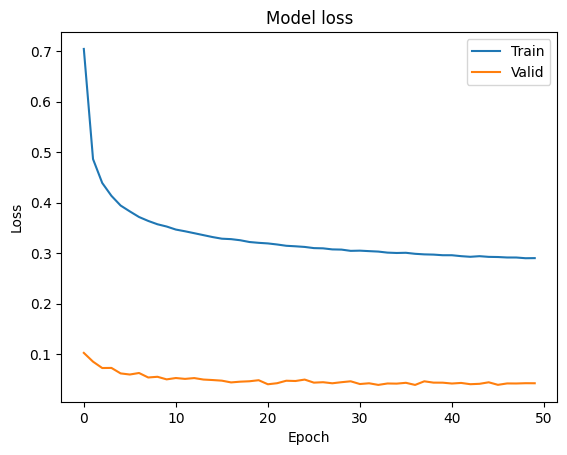

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
assert plt.legend(['Train', 'Valid'], loc='upper right')

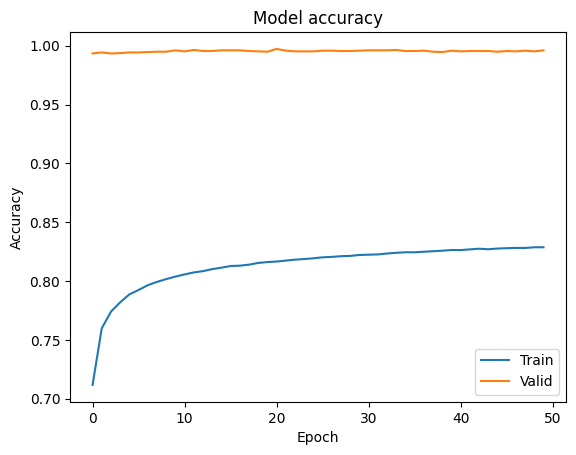

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
assert plt.legend(['Train', 'Valid'], loc='lower right')

In [ ]:
model_cls.save_weights('model.0-9_up.cls.weights.h5')
model_cls = keras.Model.from_config(model_cls.get_config())
model_cls.load_weights('model.0-9_up.cls.weights.h5')
model_cls.save('model.0-9_up.cls.keras')

In [ ]:
!md5sum 'model.0-9_up.cls.keras'

a042c1fe99bcb65d425d2878cf3f2555  model.0-9_up.cls.keras


# Bin

In [ ]:
(extra_dataset,), info = tfds.load(
    name='my_dataset', split=['train'],
    data_dir='/kaggle/input/datasets/olegmazko/tfds-balanced-is-digit-mask-distilled-from-cv12',
    with_info=True, as_supervised=True)
assert info.homepage == 'https://huggingface.co/datasets/mazkooleg/digit_mask_ensemble_distilled_from_cv12_balanced_mfcc'
assert len(extra_dataset) == 10122488, len(extra_dataset)

I0000 00:00:1777403052.478388      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [ ]:
(train_dataset, test_dataset, valid_dataset), info = tfds.load(
    name='my_dataset', split=['train', 'test', 'valid'],
    data_dir='/kaggle/input/datasets/olegmazko/tfds-is-digit-mask-distilled-mfcc',
    with_info=True)
assert info.homepage == 'https://huggingface.co/datasets/mazkooleg/digit_mask_ft_ensemble_distilled_mfcc'
assert len(train_dataset) == 1825800

In [ ]:
train_dataset = train_dataset.map(lambda d: itemgetter('mfcc', 'logits')(d))
valid_dataset = valid_dataset.map(lambda d: itemgetter('mfcc', 'logits')(d))

In [ ]:
total_ds_len = len(train_dataset) + len(extra_dataset)
assert total_ds_len == 11948288, total_ds_len

In [ ]:
train_dataset = tf.data.Dataset.sample_from_datasets(
    [train_dataset.repeat(), extra_dataset.repeat()],
    weights=[len(train_dataset) / total_ds_len, len(extra_dataset) / total_ds_len])

In [ ]:
train_dataset = train_dataset.batch(256, drop_remainder=True)
train_dataset = train_dataset.map(lambda x4, y4: (spectrogram_masking(x4, 1, 3, 3), y4))
train_dataset = train_dataset.map(lambda x5, y5: (spectrogram_masking(x5, 2, 2, 2), y5))
train_dataset = train_dataset.unbatch()

In [ ]:
model_bin = build_model(num_labels=1, name='bin')
model_bin.summary()

Model: "bin"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 47, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 47, 128)   │      1,664 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 47, 128)   │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 47, 128)   │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 47, 512)   │    196,608 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 47, 512)   │      2,048 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 47, 512)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 47, 512)   │          0 │ activation[0][0]  │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 47, 128)   │    131,072 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 47, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 47, 128)   │          0 │ batch_normalizat… │
│                     │                   │            │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 47, 128)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 47, 128)   │          0 │ activation_1[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 24, 128)   │          0 │ spatial_dropout1… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 24, 512)   │    196,608 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 512)   │      2,048 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 24, 512)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_3 │ (None, 24, 512)   │          0 │ activation_2[0][… │
│ (SpatialDropout1D)  │                   │            │                 

 Total params: 1,390,337 (5.30 MB)

 Trainable params: 1,384,193 (5.28 MB)

 Non-trainable params: 6,144 (24.00 KB)

In [ ]:
def distill_loss(temperature):
    def loss(teacher_logits, student_logit):
        soft_target = tf.nn.softmax(teacher_logits / temperature, axis=-1)[:, 1]
        student_logit_scaled = student_logit / temperature
        return tf.keras.losses.binary_crossentropy(
            soft_target,
            student_logit_scaled,
            from_logits=True)
    return loss

In [ ]:
md5 = !echo '{inspect.getsource(distill_loss).strip()}' | md5sum
assert md5[0][:32] == 'ad8d6192bee1e36cc2b66a712765832e', md5

In [ ]:
def distill_binary_accuracy(threshold=0):
    def accuracy(teacher_logits, student_logit):
        hard_label = tf.argmax(teacher_logits, axis=-1)
        return keras.metrics.binary_accuracy(
            tf.cast(hard_label, tf.float32),
            student_logit,
            threshold=threshold)
    accuracy.__name__ = 'acc'
    return accuracy

In [ ]:
md5 = !echo '{inspect.getsource(distill_binary_accuracy).strip()}' | md5sum
assert md5[0][:32] == '5095a0ca732aa67e037bd26a6ad12b8b', md5

In [ ]:
model_bin.compile(loss=distill_loss(temperature=10),
                  optimizer="adam",
                  metrics=[distill_binary_accuracy(threshold=0)])

In [ ]:
history = model_bin.fit(train_dataset.shuffle(100_000).batch(32),
                        validation_data=valid_dataset.repeat(3).batch(32),
                        epochs=BIN_TRAIN_EPOCHS, verbose=2,
                        steps_per_epoch=total_ds_len // 32)

Epoch 1/15


I0000 00:00:1777403066.226478      74 service.cc:152] XLA service 0x7a228a0504a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777403066.226527      74 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777403067.319517      74 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777403077.221699      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


373384/373384 - 2508s - 7ms/step - acc: 0.8866 - loss: 0.6179 - val_acc: 0.9962 - val_loss: 0.5505
Epoch 2/15
373384/373384 - 2462s - 7ms/step - acc: 0.9051 - loss: 0.6143 - val_acc: 0.9955 - val_loss: 0.5500
Epoch 3/15
373384/373384 - 2441s - 7ms/step - acc: 0.9100 - loss: 0.6133 - val_acc: 0.9972 - val_loss: 0.5497
Epoch 4/15
373384/373384 - 2435s - 7ms/step - acc: 0.9129 - loss: 0.6128 - val_acc: 0.9968 - val_loss: 0.5493
Epoch 5/15
373384/373384 - 2475s - 7ms/step - acc: 0.9149 - loss: 0.6125 - val_acc: 0.9975 - val_loss: 0.5494
Epoch 6/15
373384/373384 - 2632s - 7ms/step - acc: 0.9163 - loss: 0.6122 - val_acc: 0.9970 - val_loss: 0.5493
Epoch 7/15
373384/373384 - 2613s - 7ms/step - acc: 0.9176 - loss: 0.6120 - val_acc: 0.9985 - val_loss: 0.5491
Epoch 8/15
373384/373384 - 2526s - 7ms/step - acc: 0.9185 - loss: 0.6118 - val_acc: 0.9972 - val_loss: 0.5493
Epoch 9/15
373384/373384 - 2530s - 7ms/step - acc: 0.9195 - loss: 0.6116 - val_acc: 0.9981 - val_loss: 0.5490
Epoch 10/15
373384/37

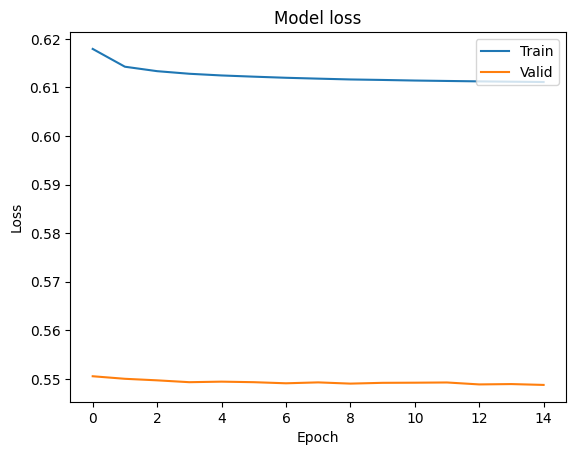

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
assert plt.legend(['Train', 'Valid'], loc='upper right')

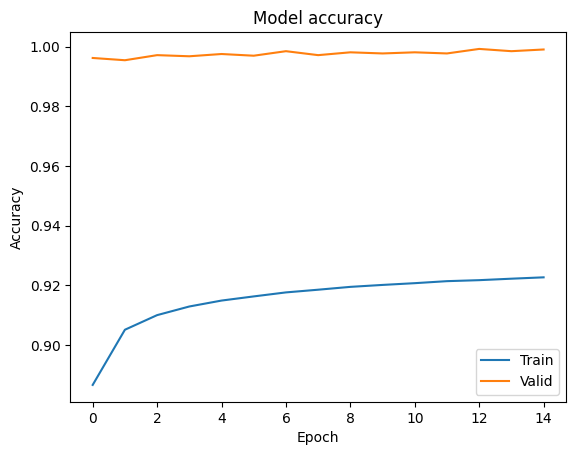

In [ ]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
assert plt.legend(['Train', 'Valid'], loc='lower right')

In [ ]:
model_bin.save_weights('model.is_digit.bin.weights.h5')
model_bin = keras.Model.from_config(model_bin.get_config())
model_bin.load_weights('model.is_digit.bin.weights.h5')
model_bin.save('model.is_digit.bin.keras')

In [ ]:
!md5sum 'model.is_digit.bin.keras'

3eba49fdda4766015b08ee0a9aebbb66  model.is_digit.bin.keras


# MC Uncertainty

### Data

In [ ]:
(train_dataset, test_dataset, valid_dataset), info = tfds.load(
    name='my_dataset', split=['train', 'test', 'valid'],
    data_dir='/kaggle/input/datasets/olegmazko/tfds-digits-commands-distilled-mfcc',
    with_info=True)
assert info.homepage == 'https://huggingface.co/datasets/mazkooleg/0-9up-ft_ensemble_distilled_mfcc'
assert len(train_dataset) == 1095480, len(train_dataset)

I0000 00:00:1777461068.741813      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [ ]:
train_dataset = train_dataset.map(lambda d: itemgetter('mfcc', 'label')(d))
valid_dataset = valid_dataset.map(lambda d: itemgetter('mfcc', 'label')(d))
train_dataset = train_dataset.shuffle(len(train_dataset), reshuffle_each_iteration=False)

In [ ]:
# 1, 2, 3, 4, 5, 6, 8, 9, 10, 12, 15, 17, 18, 20, 24, 30, 34, 36, 40, 45, 51, 60,
# 68, 72, 85, 90, 102, 120, 136, 153, 170, 179, 180, 204, 255, 306, 340, 358, 360,
# 408, 510, 537, 612, 680, 716, 765, 895, 1020, 1074, 1224, 1432, 1530, 1611, 1790,
# 2040, 2148, 2685, 3043, 3060, 3222, 3580, 4296, 5370, 6086, 6120, 6444, 7160, 8055,
# 9129, 10740, 12172, 12888, 15215, 16110, 18258, 21480, 24344, 27387, 30430, 32220,
# 36516, 45645, 54774, 60860, 64440, 73032, 91290, 109548, 121720, 136935, 182580,
# 219096, 273870, 365160, 547740
train_dataset = train_dataset.batch(255, drop_remainder=True)
train_dataset = train_dataset.map(lambda x4, y4: (spectrogram_masking(x4, 1, 3, 3), y4))
train_dataset = train_dataset.map(lambda x5, y5: (spectrogram_masking(x5, 2, 2, 2), y5))
train_dataset = train_dataset.unbatch()
assert len(train_dataset) == 1095480

In [ ]:
model_mc = build_model(num_labels=12, num_units=256, dropout=0.5, name='mc')
model_mc.summary()

Model: "mc"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 47, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 47, 256)   │      3,328 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 47, 256)   │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 47, 256)   │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 47, 1024)  │    786,432 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 47, 1024)  │      4,096 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 47, 1024)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 47, 1024)  │          0 │ activation[0][0]  │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 47, 256)   │    524,288 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 47, 256)   │      1,024 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 47, 256)   │          0 │ batch_normalizat… │
│                     │                   │            │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 47, 256)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 47, 256)   │          0 │ activation_1[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 24, 256)   │          0 │ spatial_dropout1… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 24, 1024)  │    786,432 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 1024)  │      4,096 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 24, 1024)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_3 │ (None, 24, 1024)  │          0 │ activation_2[0][… │
│ (SpatialDropout1D)  │                   │            │                 

 Total params: 5,536,012 (21.12 MB)

 Trainable params: 5,523,724 (21.07 MB)

 Non-trainable params: 12,288 (48.00 KB)

In [ ]:
model_mc.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                 optimizer="adam", metrics=['accuracy'])

In [ ]:
history = model_mc.fit(train_dataset.shuffle(len(train_dataset)//8).batch(32),
                       validation_data=valid_dataset.repeat(3).batch(32),
                       epochs=UNC_TRAIN_EPOCHS, verbose=2)

Epoch 1/25


I0000 00:00:1777461130.656933      77 service.cc:152] XLA service 0x18e4d8c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777461130.656978      77 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777461131.837864      77 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777461144.528642      77 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


34234/34234 - 518s - 15ms/step - accuracy: 0.7138 - loss: 1.1165 - val_accuracy: 0.9371 - val_loss: 0.2056
Epoch 2/25
34234/34234 - 483s - 14ms/step - accuracy: 0.8597 - loss: 0.4629 - val_accuracy: 0.9623 - val_loss: 0.1203
Epoch 3/25
34234/34234 - 486s - 14ms/step - accuracy: 0.8857 - loss: 0.3792 - val_accuracy: 0.9697 - val_loss: 0.0939
Epoch 4/25
34234/34234 - 481s - 14ms/step - accuracy: 0.8983 - loss: 0.3380 - val_accuracy: 0.9727 - val_loss: 0.0820
Epoch 5/25
34234/34234 - 487s - 14ms/step - accuracy: 0.9072 - loss: 0.3090 - val_accuracy: 0.9768 - val_loss: 0.0722
Epoch 6/25
34234/34234 - 492s - 14ms/step - accuracy: 0.9133 - loss: 0.2899 - val_accuracy: 0.9798 - val_loss: 0.0613
Epoch 7/25
34234/34234 - 493s - 14ms/step - accuracy: 0.9183 - loss: 0.2734 - val_accuracy: 0.9831 - val_loss: 0.0554
Epoch 8/25
34234/34234 - 484s - 14ms/step - accuracy: 0.9215 - loss: 0.2623 - val_accuracy: 0.9813 - val_loss: 0.0568
Epoch 9/25
34234/34234 - 488s - 14ms/step - accuracy: 0.9263 - loss

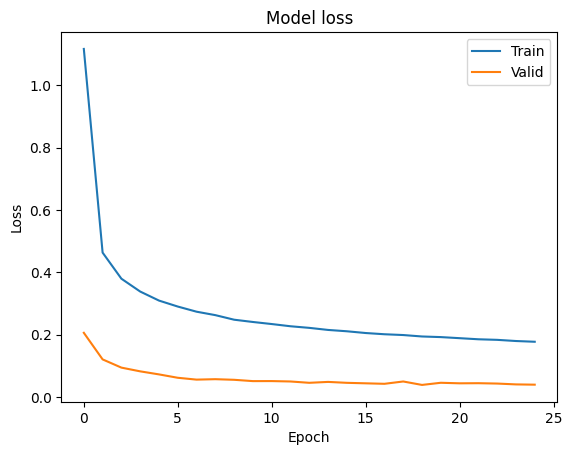

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
assert plt.legend(['Train', 'Valid'], loc='upper right')

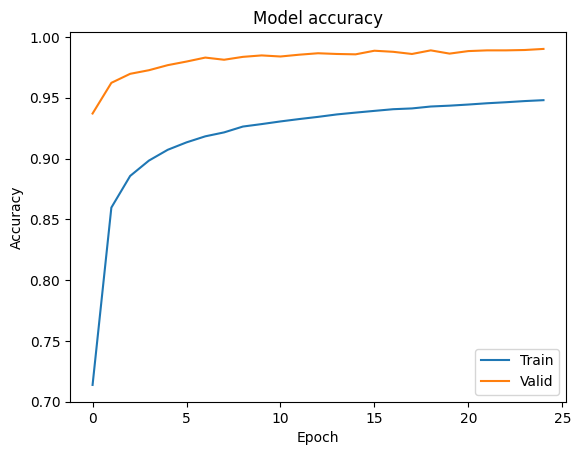

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
assert plt.legend(['Train', 'Valid'], loc='lower right')

In [ ]:
%%writefile mc_uncertainty.py
import keras
import tensorflow as tf
class MCUncertainty(keras.layers.Layer):
  """Runs N forward passes with dropout active, returns max variance across classes."""
  def __init__(self, model, n_passes, **kwargs):
    super().__init__(**kwargs)
    self.model    = model
    self.n_passes = n_passes

  def call(self, x):
    # tile batch to run all N passes in a single forward call
    # (batch, 47, 13) -> (batch*N, 47, 13)
    x_tiled = tf.repeat(x, repeats=self.n_passes, axis=0)

    # dropout stays active — each copy gets a different random mask
    logits = self.model(x_tiled, training=True)           # (batch*N, 12)
    probs  = tf.nn.softmax(logits, axis=-1)               # (batch*N, 12)

    # restore batch dimension: (batch*N, 12) -> (batch, N, 12)
    n_classes = logits.shape[-1]
    probs = tf.reshape(probs, (-1, self.n_passes, n_classes))

    # variance across N passes, max across classes -> scalar per sample
    std = tf.math.reduce_std(probs, axis=1)   # (batch, 12)
    return tf.math.reduce_max(std, axis=-1)   # (batch,)

Writing mc_uncertainty.py


In [ ]:
from mc_uncertainty import MCUncertainty

In [ ]:
md5 = !echo '{inspect.getsource(MCUncertainty).strip()}' | md5sum
assert md5[0][:32] == '9665a593f59f8e186f9723a661354e1f', md5

In [ ]:
def build_mc_wrapper(model, n_passes):
  """Takes (batch, 47, 13), returns (batch,) scalar uncertainty via MC Dropout."""
  inputs      = keras.Input(shape=model.input_shape[1:])
  uncertainty = MCUncertainty(model, n_passes)(inputs)
  return keras.Model(inputs, uncertainty, name='mc_uncertainty')

In [ ]:
(train_dataset, test_dataset, valid_dataset), info = tfds.load(
    name='my_dataset', split=['train', 'test', 'valid'],
    data_dir='/kaggle/input/datasets/olegmazko/tfds-is-digit-mask-distilled-mfcc',
    with_info=True)
assert info.homepage == 'https://huggingface.co/datasets/mazkooleg/digit_mask_ft_ensemble_distilled_mfcc'
assert len(train_dataset) == 1825800

In [ ]:
train_dataset = train_dataset.map(lambda d: itemgetter('mfcc', 'label')(d))
valid_dataset = valid_dataset.map(lambda d: itemgetter('mfcc', 'label')(d))
test_dataset  = test_dataset.map(lambda d: itemgetter('mfcc', 'label')(d))

In [ ]:
PRED_KW = dict(batch_size=32, verbose=0)

# reuse bin dataset already loaded and cached:
#   y == 1 -> digits       (known,   expect low variance)
#   y == 0 -> LibriSpeech  (unknown, expect high variance)
model_mc_wrapper = build_mc_wrapper(model_mc, n_passes=500)

print("Computing MC Dropout variance on known (digits)...")
x_known_train   = np.array(list(train_dataset.filter(lambda _a, y: y == 1).map(lambda x, _b: x)), 'float32')
unc_known_train = model_mc_wrapper.predict(x_known_train, **PRED_KW)

print("Computing MC Dropout variance on unknown (LibriSpeech)...")
x_unknown_train   = np.array(list(train_dataset.filter(lambda _c, y: y == 0).map(lambda x, _d: x)), 'float32')
unc_unknown_train = model_mc_wrapper.predict(x_unknown_train, **PRED_KW)

print("Computing MC Dropout variance on valid...")
x_known_valid   = np.array(list(valid_dataset.filter(lambda _e, y: y == 1).map(lambda x, _f: x)), 'float32')
unc_known_valid = model_mc_wrapper.predict(x_known_valid, **PRED_KW)
x_unknown_valid   = np.array(list(valid_dataset.filter(lambda _g, y: y == 0).map(lambda x, _h: x)), 'float32')
unc_unknown_valid = model_mc_wrapper.predict(x_unknown_valid, **PRED_KW)

print("Computing MC Dropout variance on test...")
x_known_test   = np.array(list(test_dataset.filter(lambda _e, y: y == 1).map(lambda x, _f: x)), 'float32')
unc_known_test = model_mc_wrapper.predict(x_known_test, **PRED_KW)
x_unknown_test   = np.array(list(test_dataset.filter(lambda _g, y: y == 0).map(lambda x, _h: x)), 'float32')
unc_unknown_test = model_mc_wrapper.predict(x_unknown_test, **PRED_KW)

Computing MC Dropout variance on known (digits)...


2026-04-29 14:40:01.937606: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv.12 = (f32[16000,1024,1,47]{3,2,1,0}, u8[0]{0}) custom-call(f32[16000,256,1,47]{3,2,1,0} %bitcast.21927, f32[1024,256,1,3]{3,2,1,0} %bitcast.21931), window={size=1x3 pad=0_0x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op_type="Conv2D" op_name="mc_uncertainty_1/mc_uncertainty_1/mc_1/conv1d_1/convolution" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-04-29 14:40:01.963589: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.026133705s
Trying algorithm eng28{k2=4,k3=0} fo

Computing MC Dropout variance on unknown (LibriSpeech)...
Computing MC Dropout variance on valid...
Computing MC Dropout variance on test...


In [ ]:
np.savez_compressed('0-9up-mc.npz',
                    x_known_train = x_known_train, unc_known_train = unc_known_train,
                    x_known_test  = x_known_test,  unc_known_test  = unc_known_test,
                    x_known_valid = x_known_valid, unc_known_valid = unc_known_valid,
                    x_unknown_train = x_unknown_train, unc_unknown_train = unc_unknown_train,
                    x_unknown_test  = x_unknown_test,  unc_unknown_test  = unc_unknown_test,
                    x_unknown_valid = x_unknown_valid, unc_unknown_valid = unc_unknown_valid)

In [ ]:
!md5sum '0-9up-mc.npz'

e2a68ea8e02a1dade51c9ced7e4dec7a  0-9up-mc.npz


### Model

In [ ]:
dset = np.load('0-9up-mc.npz')

In [ ]:
x_known_train = dset['x_known_train']
unc_known_train = dset['unc_known_train']
x_known_test  = dset['x_known_test']
unc_known_test  = dset['unc_known_test']
x_known_valid = dset['x_known_valid']
unc_known_valid = dset['unc_known_valid']
x_unknown_train = dset['x_unknown_train']
unc_unknown_train = dset['unc_unknown_train']
x_unknown_test  = dset['x_unknown_test']
unc_unknown_test  = dset['unc_unknown_test']
x_unknown_valid = dset['x_unknown_valid']
unc_unknown_valid = dset['unc_unknown_valid']

In [ ]:
print(f"known   unc: mean={unc_known_train.mean():.5f}  n={len(unc_known_train)}")
print(f"unknown unc: mean={unc_unknown_train.mean():.5f}  n={len(unc_unknown_train)}")
print(f"separability: {unc_unknown_train.mean()/unc_known_train.mean():.1f}x")

print(f"known   unc: mean={unc_known_valid.mean():.5f}  n={len(unc_known_valid)}")
print(f"unknown unc: mean={unc_unknown_valid.mean():.5f}  n={len(unc_unknown_valid)}")
print(f"separability: {unc_unknown_valid.mean()/unc_known_valid.mean():.1f}x")

print(f"known   unc: mean={unc_known_test.mean():.5f}  n={len(unc_known_test)}")
print(f"unknown unc: mean={unc_unknown_test.mean():.5f}  n={len(unc_unknown_test)}")
print(f"separability: {unc_unknown_test.mean()/unc_known_test.mean():.1f}x")

known   unc: mean=0.08664  n=912900
unknown unc: mean=0.32200  n=912900
separability: 3.7x
known   unc: mean=0.06077  n=2638
unknown unc: mean=0.32350  n=2638
separability: 5.3x
known   unc: mean=0.07439  n=3043
unknown unc: mean=0.32006  n=3043
separability: 4.3x


In [ ]:
x_distill_train = np.concatenate([x_known_train,   x_unknown_train])
y_distill_train = np.concatenate([unc_known_train, unc_unknown_train])

x_distill_valid = np.concatenate([x_known_valid,   x_unknown_valid])
y_distill_valid = np.concatenate([unc_known_valid, unc_unknown_valid])

print(f"Distill train: {len(x_distill_train)} samples")
print(f"Distill valid: {len(x_distill_valid)} samples")

Distill train: 1825800 samples
Distill valid: 5276 samples


In [ ]:
model_unc = build_model(num_labels=1, dropout=.2, name=None)
model_unc.summary()
model_unc.compile(optimizer='adam', loss='mae')

I0000 00:00:1777583696.183915      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 47, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 47, 128)   │      1,664 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 47, 128)   │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 47, 128)   │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 47, 512)   │    196,608 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 47, 512)   │      2,048 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 47, 512)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 47, 512)   │          0 │ activation[0][0]  │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 47, 128)   │    131,072 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 47, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 47, 128)   │          0 │ batch_normalizat… │
│                     │                   │            │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 47, 128)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 47, 128)   │          0 │ activation_1[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 24, 128)   │          0 │ spatial_dropout1… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 24, 512)   │    196,608 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 512)   │      2,048 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 24, 512)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_3 │ (None, 24, 512)   │          0 │ activation_2[0][… │
│ (SpatialDropout1D)  │                   │            │                 

 Total params: 1,390,337 (5.30 MB)

 Trainable params: 1,384,193 (5.28 MB)

 Non-trainable params: 6,144 (24.00 KB)

In [ ]:
history_unc = model_unc.fit(
    x_distill_train, y_distill_train,
    validation_data=(x_distill_valid, y_distill_valid),
    batch_size=32, epochs=UNC_TRAIN_EPOCHS, verbose=2,
    callbacks=[keras.callbacks.ReduceLROnPlateau()])

Epoch 1/100


I0000 00:00:1777583715.608541      72 service.cc:152] XLA service 0x79b474027110 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777583715.608583      72 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777583716.773366      72 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777583728.035848      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


57057/57057 - 414s - 7ms/step - loss: 0.0777 - val_loss: 0.0403 - learning_rate: 1.0000e-03
Epoch 2/100
57057/57057 - 391s - 7ms/step - loss: 0.0495 - val_loss: 0.0414 - learning_rate: 1.0000e-03
Epoch 3/100
57057/57057 - 390s - 7ms/step - loss: 0.0457 - val_loss: 0.0333 - learning_rate: 1.0000e-03
Epoch 4/100
57057/57057 - 389s - 7ms/step - loss: 0.0434 - val_loss: 0.0332 - learning_rate: 1.0000e-03
Epoch 5/100
57057/57057 - 389s - 7ms/step - loss: 0.0418 - val_loss: 0.0318 - learning_rate: 1.0000e-03
Epoch 6/100
57057/57057 - 388s - 7ms/step - loss: 0.0407 - val_loss: 0.0319 - learning_rate: 1.0000e-03
Epoch 7/100
57057/57057 - 391s - 7ms/step - loss: 0.0398 - val_loss: 0.0310 - learning_rate: 1.0000e-03
Epoch 8/100
57057/57057 - 390s - 7ms/step - loss: 0.0391 - val_loss: 0.0312 - learning_rate: 1.0000e-03
Epoch 9/100
57057/57057 - 390s - 7ms/step - loss: 0.0385 - val_loss: 0.0295 - learning_rate: 1.0000e-03
Epoch 10/100
57057/57057 - 399s - 7ms/step - loss: 0.0380 - val_loss: 0.0301

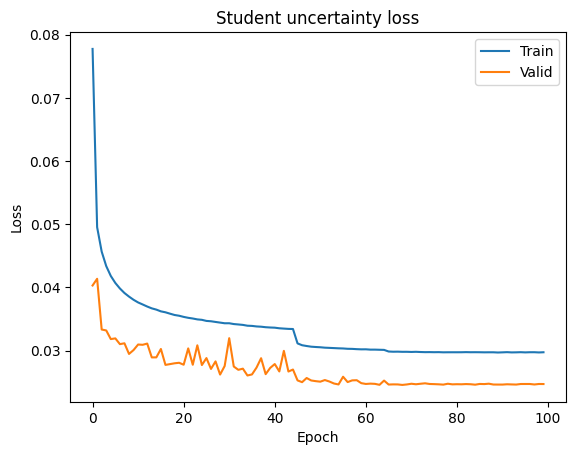

In [ ]:
plt.plot(history_unc.history['loss'])
plt.plot(history_unc.history['val_loss'])
plt.title('Student uncertainty loss')
plt.ylabel('Loss'); plt.xlabel('Epoch')
assert plt.legend(['Train', 'Valid'], loc='upper right')

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score

unc_pred_known   = model_unc.predict(x_known_valid,   batch_size=256, verbose=0)
unc_pred_unknown = model_unc.predict(x_unknown_valid, batch_size=256, verbose=0)

print(f"Student known   mean={unc_pred_known.mean():.5f}")
print(f"Student unknown mean={unc_pred_unknown.mean():.5f}")
print(f"separability: {unc_pred_unknown.mean()/unc_pred_known.mean():.1f}x")

labels = np.concatenate([np.ones(len(unc_pred_known)), np.zeros(len(unc_pred_unknown))])
scores = np.concatenate([unc_pred_known, unc_pred_unknown])

best_f1, best_t = 0, 0
for t in np.linspace(scores.min(), scores.max(), 300):
  f1 = f1_score(labels, (scores < t).astype(int), zero_division=0)
  if f1 > best_f1:
    best_f1, best_t = f1, t

auc = roc_auc_score(labels, -scores)
tpr = (unc_pred_known   < best_t).mean()
fpr = (unc_pred_unknown < best_t).mean()

print(f"\nAUC={auc:.3f}  F1={best_f1:.3f}  TPR={tpr:.1%}  FPR={fpr:.1%}")
print(f"uncertainty threshold: {best_t:.6f}")
UNCERTAINTY_THRESHOLD = float(best_t)

Student known   mean=0.05044
Student unknown mean=0.32384
separability: 6.4x

AUC=0.987  F1=0.954  TPR=96.1%  FPR=5.3%
uncertainty threshold: 0.221356


In [ ]:
# Rescaling(scale=-1/threshold, offset=1)(unc)
# = unc * (-1/threshold) + 1
# = 1 - unc/threshold
# = (threshold - unc) / threshold
model_unc = keras.Sequential([
    model_unc,
    keras.layers.Rescaling(
        scale=-1 / max(UNCERTAINTY_THRESHOLD, 1e-8),
        offset=1)
], name="unc")

In [ ]:
model_unc.save_weights('model.0-9.unc.weights.h5')
model_unc = keras.Sequential.from_config(model_unc.get_config())
model_unc.load_weights('model.0-9.unc.weights.h5')
model_unc.save('model.0-9.unc.keras')

In [ ]:
unc_pred_known   = model_unc.predict(x_known_valid,   batch_size=256, verbose=0)
unc_pred_unknown = model_unc.predict(x_unknown_valid, batch_size=256, verbose=0)

print(f"Student known   mean={unc_pred_known.mean():.5f}")
print(f"Student unknown mean={unc_pred_unknown.mean():.5f}")

labels = np.concatenate([np.ones(len(unc_pred_known)), np.zeros(len(unc_pred_unknown))])
scores = np.concatenate([unc_pred_known, unc_pred_unknown])

auc = roc_auc_score(labels, scores)
tpr = (unc_pred_known   > 0).mean()
fpr = (unc_pred_unknown > 0).mean()
f1 = f1_score(labels, (scores > 0).astype(int), zero_division=0)

print(f"\nAUC={auc:.3f}  F1={f1:.3f}  TPR={tpr:.1%}  FPR={fpr:.1%}")

Student known   mean=0.77213
Student unknown mean=-0.46298

AUC=0.987  F1=0.954  TPR=96.1%  FPR=5.3%


In [ ]:
!md5sum 'model.0-9.unc.keras'

765355195f351d730da0214587059b32  model.0-9.unc.keras


# Target NN

In [ ]:
model_cls = keras.models.load_model('model.0-9_up.cls.keras')
model_bin = keras.models.load_model('model.is_digit.bin.keras')
model_unc = keras.models.load_model('model.0-9.unc.keras')

2026-05-01 12:07:27.577680: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
def build_target_model(unc_temperature):
  i = keras.Input(shape=model_cls.input_shape[1:])

  # CLS: softmax over 12 classes
  c = keras.layers.Activation('softmax')(model_cls(i))         # (batch, 12)

  # BIN: probability that input contains a digit
  b = keras.layers.Activation('sigmoid')(model_bin(i))         # (batch,)

  # UNC: predicted variance -> confidence score
  u = unc_temperature
  u = keras.layers.Activation('sigmoid')(u * model_unc(i))     # (batch,)

  # split CLS into digits 0-9 and classes "up"/"background"
  c = keras.layers.Reshape((-1, 1))(c)
  l = keras.layers.Cropping1D(cropping=[0, 2])(c)              # first 10: digits
  l = keras.layers.Reshape((10,))(l)
  r = keras.layers.Cropping1D(cropping=[10, 0])(c)             # last 2: up + bg
  r = keras.layers.Reshape((2,))(r)

  # digits weighted by BIN and UNC; "up"/"bg" classes are unaffected
  o = keras.layers.Multiply()([l, b, u])
  o = keras.layers.Concatenate(axis=-1)([o, r])
  o = keras.layers.Activation('softmax')(keras.ops.log(o + 1e-8))
  return keras.Model(inputs=i, outputs=o, name='target')

In [ ]:
md5 = !echo '{inspect.getsource(build_target_model).strip()}' | md5sum
assert md5[0][:32] == '41a81f8a29f101eee859ef474739b607', md5

In [ ]:
target = build_target_model(unc_temperature=3)
target.summary()

Model: "target"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 47, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls (Functional)    │ (None, 12)        │  1,391,756 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 12)        │          0 │ cls[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 12, 1)     │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unc (Sequential)    │ (None)            │  1,390,337 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cropping1d          │ (None, 10, 1)     │          0 │ reshape[0][0]     │
│ (Cropping1D)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bin (Functional)    │ (None)            │  1,390,337 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None)            │          0 │ unc[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 10)        │          0 │ cropping1d[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None)            │          0 │ bin[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None)            │          0 │ multiply[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cropping1d_1        │ (None, 2, 1)      │          0 │ reshape[0][0]     │
│ (Cropping1D)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 10)        │          0 │ reshape_1[0][0],  │
│ (Multiply)          │                   │            │ activation_1[0][… │
│                     │                   │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 2)         │          0 │ cropping1d_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 12)        │          0 │ multiply_1[0][0], │
│ (Concatenate)       │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 12)        │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log (Log)           │ (None, 12)        │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 12)        │          0 │ log[0][0]         │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,172,430 (15.92 MB)

 Trainable params: 4,153,998 (15.85 MB)

 Non-trainable params: 18,432 (72.00 KB)

In [ ]:
def convert_model(model, dtype=tf.float32,
                  optimizations=None, supported_types=None):

    @tf.function(input_signature=[tf.TensorSpec([1, *model.input_shape[1:]], dtype)])
    def serving(x):
        return model(x, training=False)

    converter = tf.lite.TFLiteConverter.from_concrete_functions(
        [serving.get_concrete_function()], trackable_obj=model
    )

    if optimizations:
        converter.optimizations = optimizations
    if supported_types:
        converter.target_spec.supported_types = supported_types

    return converter.convert()

In [ ]:
md5 = !echo '{inspect.getsource(convert_model).strip()}' | md5sum
assert md5[0][:32] == '0145274f62734dbd340f0554c0180e71', md5

In [ ]:
pathlib.Path('target.tflite').write_bytes(convert_model(target))
!md5sum 'target.tflite'

I0000 00:00:1777637250.603502      16 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1777637250.603830      16 single_machine.cc:374] Starting new session
W0000 00:00:1777637252.139160      16 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777637252.139208      16 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


d66c5b9841a46b62a356ec74143d57bb  target.tflite


In [ ]:
pathlib.Path('target.opt.tflite').write_bytes(
    convert_model(target, optimizations=[tf.lite.Optimize.DEFAULT]))
!md5sum 'target.opt.tflite'

I0000 00:00:1777637255.122083      16 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1777637255.122386      16 single_machine.cc:374] Starting new session


e0266cdc48bb726794cab2010630ab06  target.opt.tflite


W0000 00:00:1777637256.782863      16 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777637256.782952      16 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


In [ ]:
!pip install -qqq --progress-bar off ai-edge-litert

In [ ]:
from ai_edge_litert.interpreter import Interpreter
interpreter = Interpreter(model_path='target.tflite')
interpreter.allocate_tensors()
test_input = np.ones((1, 47, 13), 'float32')
interpreter.set_tensor(interpreter.get_input_details()[0]['index'], test_input)
interpreter.invoke()
tflite_out = interpreter.get_tensor(interpreter.get_output_details()[0]['index'])
keras_out  = target(test_input).numpy()
assert np.allclose(keras_out, tflite_out, atol=1e-4), f'Mismatch: {keras_out} vs {tflite_out}'
print('TFLite OK:', tflite_out)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


TFLite OK: [[4.4703287e-07 6.0224249e-07 1.1452338e-06 6.4658468e-07 7.0641124e-07
  5.4714076e-07 3.9388968e-07 2.4402814e-07 1.3242570e-06 4.4889850e-07
  1.1073888e-03 9.9888617e-01]]
